
# Synthetic Drift — 1 File, Labels, 3× Windows × 4× Metrics

**Qué hace este notebook**  
- Genera **1 solo dataset** sintético (25–30 días, frecuencia horaria) con **10 variables numéricas**.  
- Inyecta **drift aleatorio** por variable (episodios **graduales** y **abruptos**), con intensidad **sutil** por defecto.  
- Crea columnas de **disponibilidad** `nd_var_*` y un **flags CSV** para enmascarar datos faltantes sin contaminar las métricas.  
- **Etiqueta** el drift: `drift_any` + `drift_var_*` (por variable) para evaluación posterior.  
- Ejecuta de una: **3 estrategias** de referencia (`decay`, `golden`, `seasonal`) × **4 métodos** (`ks`, `mannwhitney`, `psi`, `wasserstein`).  
- Produce **CSV unificados** por planta y globales (summary + columns) para comparar todas las combinaciones.



## 1) Parámetros
- `N_DAYS` se elige entre 25 y 30.
- `N_VARS = 10`.
- Drift **gradual**: incrementos de 0.2–0.6 distribuidos linealmente.
- Drift **abrupto**: salto 0.8–1.5 (puede ajustarse abajo).
- Se agregan **bloques faltantes** por variable para poblar `nd_var_i`.


In [1]:

import numpy as np, pandas as pd
from pathlib import Path
from datetime import timedelta
import importlib.util

spec = importlib.util.spec_from_file_location("funciones_analisis", "../Analisis/Funciones_Drift.py")
funciones_analisis = importlib.util.module_from_spec(spec)
spec.loader.exec_module(funciones_analisis)
run_drift_aggregate = funciones_analisis.run_drift_aggregate

# ----- reproducibilidad -----
rng = np.random.default_rng(2270)

# ----- parámetros base -----
N_DAYS = int(rng.integers(30, 46))        # 30–45 días
FREQ = "1H"
N_VARS = 10

PLANT_NAME = "synthetic_plant"
OUT_ROOT = Path("drift_results_v2")
DATA_DIR = Path("synthetic_data_v2")
DATA_DIR.mkdir(exist_ok=True, parents=True)

print(f"N_DAYS={N_DAYS}, N_VARS={N_VARS}")

N_DAYS=43, N_VARS=10



## 2) Generación del dataset sintético + etiquetas de drift
- Cada `var_i` parte como ruido gaussiano `N(0,1)`.
- Se eligen 1–3 episodios de drift por variable.
- **Gradual**: rampa lineal suave (0.2–0.6) durante 1–5 días.
- **Abrupto**: salto 0.8–1.5 a partir del inicio del episodio.
- Se construyen etiquetas: `drift_var_i` y `drift_any` por timestamp.


In [ ]:
# ----- eje temporal -----
dates = pd.date_range("2025-01-01", periods=N_DAYS*24, freq=FREQ, tz=None)
df = pd.DataFrame({"date_time": dates})

# etiquetas por variable y global
drift_flags = pd.DataFrame({"date_time": dates})
for i in range(1, N_VARS+1):
    drift_flags[f"drift_var_{i}"] = False

# ----- construir variables + inyectar drift -----
for i in range(1, N_VARS+1):
    base = rng.normal(0.0, 1.0, size=len(dates))
    
    n_episodes = int(rng.integers(1, 4))  # 1–3 episodios por variable
    for _ in range(n_episodes):
        # inicio no demasiado al principio ni al final (más disperso)
        start_idx = int(rng.integers(low=24*2, high=len(dates)-24*2))
        drift_kind = rng.choice(["gradual", "abrupt"])
        
        if drift_kind == "gradual":
            # duración 1–5 días
            dur_hours = int(rng.integers(24, 24*5+1))
            end_idx = min(len(dates)-1, start_idx + dur_hours)
            # incremento sutil total 0.2–0.6
            total_shift = float(rng.uniform(0.2, 0.6))
            ramp = np.linspace(0.0, total_shift, end_idx - start_idx + 1)
            base[start_idx:end_idx+1] += ramp
            drift_flags.loc[start_idx:end_idx, f"drift_var_{i}"] = True
        else:
            # salto abrupto 0.8–1.5
            jump = float(rng.uniform(0.8, 1.5))
            base[start_idx:] += jump
            drift_flags.loc[start_idx:, f"drift_var_{i}"] = True
    
    df[f"var_{i}"] = base

# etiqueta global (cualquier variable con drift activa en t)
drift_cols = [c for c in drift_flags.columns if c.startswith("drift_var_")]
drift_flags["drift_any"] = drift_flags[drift_cols].any(axis=1)

(            date_time     var_1     var_2     var_3     var_4     var_5  \
 0 2025-01-01 00:00:00 -2.173054 -0.587351  0.016059 -0.307996  0.384627   
 1 2025-01-01 01:00:00 -0.681144 -0.773636 -0.327268  0.245469  0.860057   
 2 2025-01-01 02:00:00 -0.490341  0.075189  0.161805  0.953240 -0.218211   
 
       var_6     var_7     var_8     var_9    var_10  
 0 -0.781963 -0.653374  0.056936 -0.395811  0.579835  
 1 -0.106955  0.146178  0.758158  0.800864  0.085178  
 2 -0.422237 -1.070472  0.252214 -1.049094 -0.148897  ,
             date_time  drift_var_1  drift_var_2  drift_var_3  drift_var_4  \
 0 2025-01-01 00:00:00        False        False        False        False   
 1 2025-01-01 01:00:00        False        False        False        False   
 2 2025-01-01 02:00:00        False        False        False        False   
 
    drift_var_5  drift_var_6  drift_var_7  drift_var_8  drift_var_9  \
 0        False        False        False        False        False   
 1        False  

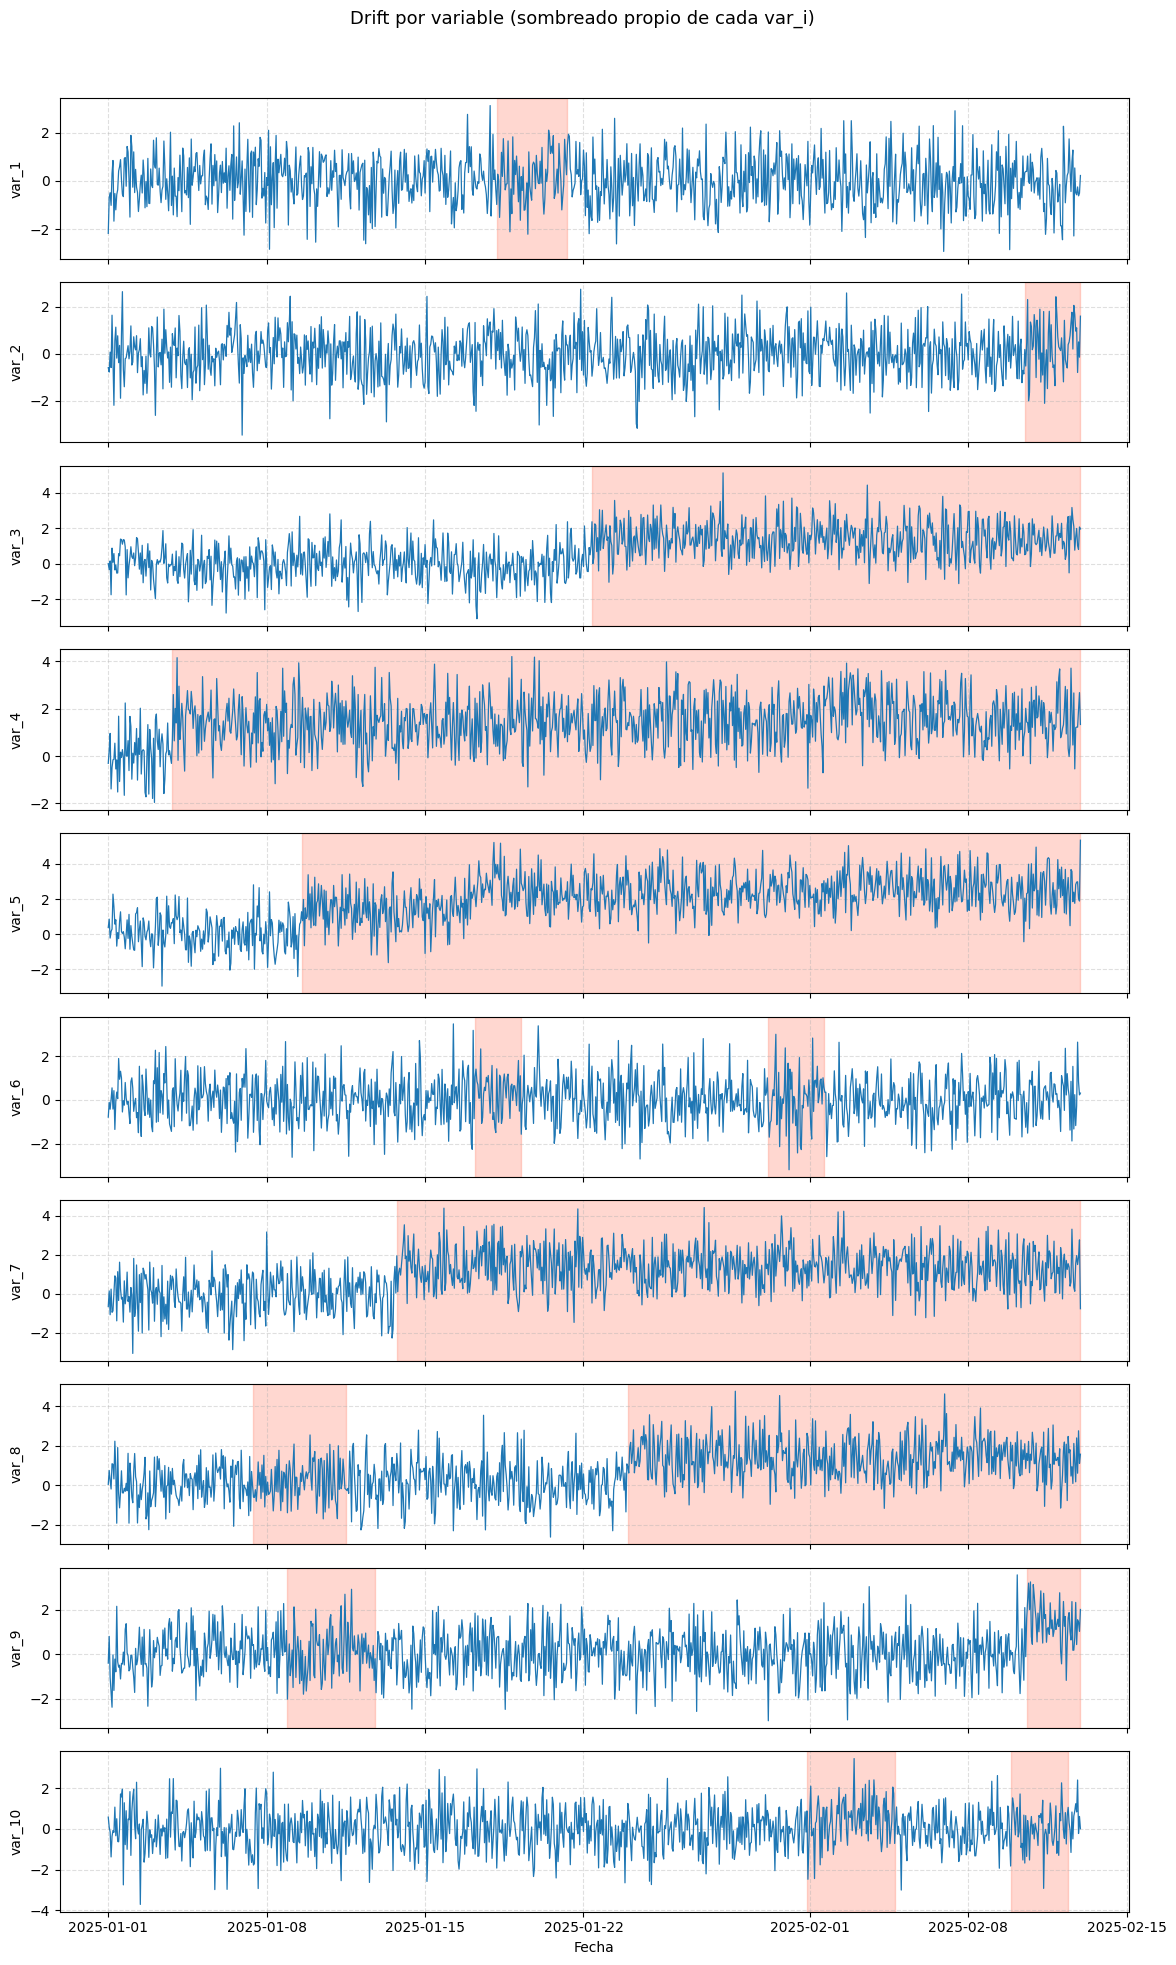

In [3]:
# === Visualización por variable con su propio drift ===
import matplotlib.pyplot as plt

vars_to_plot = [f"var_{i}" for i in range(1, N_VARS+1)]
times = df["date_time"]

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(12, 2.0*len(vars_to_plot)), sharex=True)

for ax, v in zip(axes, vars_to_plot):
    ax.plot(times, df[v], lw=0.9, label=v)
    mask = drift_flags["drift_" + v].astype(bool).values
    in_drift = False; start = None
    for i in range(len(mask)):
        if mask[i] and not in_drift:
            start = times[i]; in_drift = True
        elif not mask[i] and in_drift:
            ax.axvspan(start, times[i], color="tomato", alpha=0.25)
            in_drift = False
    if in_drift:
        ax.axvspan(start, times.iloc[-1], color="tomato", alpha=0.25)
    ax.set_ylabel(v)
    ax.grid(True, ls="--", alpha=0.4)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Drift por variable (sombreado propio de cada var_i)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [4]:
# === Primer inicio y último fin de drift por variable ===
rows = []
for i in range(1, N_VARS+1):
    lab = f"drift_var_{i}"
    s = drift_flags[lab].astype(bool)
    intervals = []
    in_drift = False; t0 = None
    for t, val in zip(df["date_time"], s):
        if val and not in_drift:
            t0 = t; in_drift = True
        elif not val and in_drift:
            intervals.append((t0, t)); in_drift = False
    if in_drift:
        intervals.append((t0, df["date_time"].iloc[-1]))
    if intervals:
        rows.append({
            "var": f"var_{i}",
            "n_episodios": len(intervals),
            "primer_inicio": intervals[0][0],
            "ultimo_fin": intervals[-1][1]
        })
    else:
        rows.append({"var": f"var_{i}", "n_episodios": 0, "primer_inicio": None, "ultimo_fin": None})

pd.DataFrame(rows)

,var,n_episodios,primer_inicio,ultimo_fin
0,var_1,1,2025-01-18 04:00:00,2025-01-21 06:00:00
1,var_2,1,2025-02-10 12:00:00,2025-02-12 23:00:00
2,var_3,1,2025-01-22 09:00:00,2025-02-12 23:00:00
3,var_4,1,2025-01-03 20:00:00,2025-02-12 23:00:00
4,var_5,1,2025-01-09 13:00:00,2025-02-12 23:00:00
5,var_6,2,2025-01-17 05:00:00,2025-02-01 15:00:00
6,var_7,1,2025-01-13 18:00:00,2025-02-12 23:00:00
7,var_8,2,2025-01-07 10:00:00,2025-02-12 23:00:00
8,var_9,2,2025-01-08 22:00:00,2025-02-12 23:00:00
9,var_10,2,2025-01-31 21:00:00,2025-02-12 10:00:00


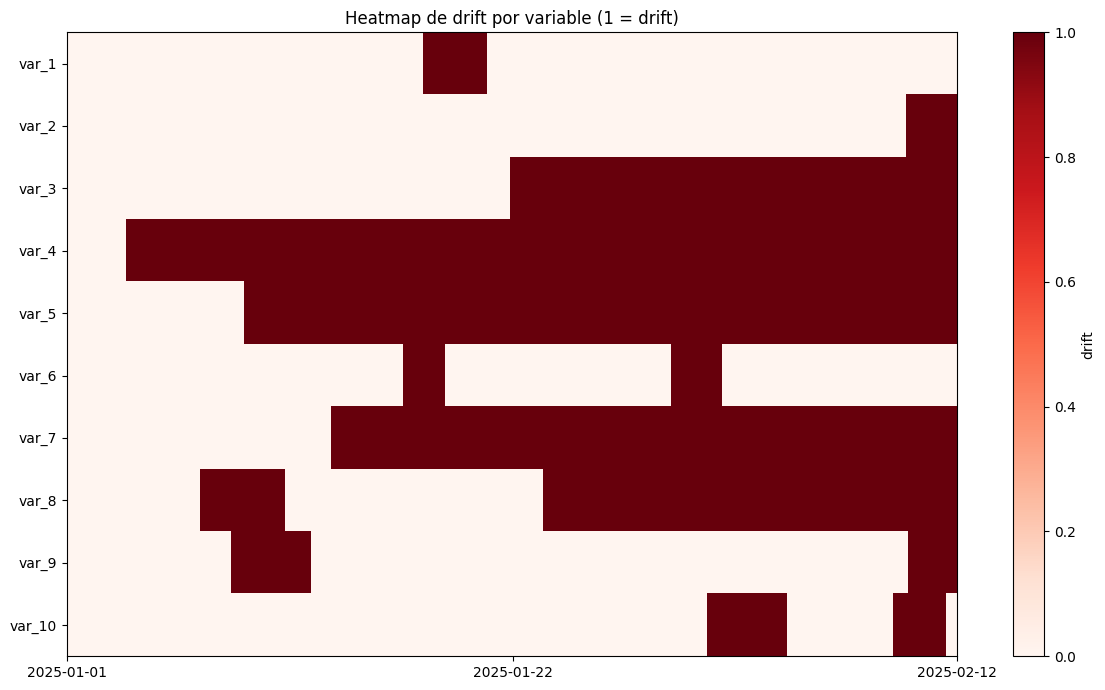

In [5]:
# === Mapa de calor (tiempo × variable) de drift (0/1) ===
import numpy as np
import matplotlib.pyplot as plt

lab_cols = [c for c in drift_flags.columns if c.startswith("drift_var_")]
M = drift_flags[lab_cols].astype(int).to_numpy().T  # (vars × tiempo)

plt.figure(figsize=(12, 0.5*len(lab_cols)+2))
plt.imshow(M, aspect="auto", interpolation="nearest", cmap="Reds")
plt.yticks(range(len(lab_cols)), [c.replace("drift_","") for c in lab_cols])
plt.xticks([0, len(df)//2, len(df)-1],
           [str(df["date_time"].iloc[0].date()),
            str(df["date_time"].iloc[len(df)//2].date()),
            str(df["date_time"].iloc[-1].date())])
plt.title("Heatmap de drift por variable (1 = drift)", fontsize=12)
plt.colorbar(label="drift")
plt.tight_layout()
plt.show()



## 3) Simular disponibilidad: columnas `nd_var_*` y enmascarar datos vía *flags CSV*
- Para cada `var_i` se crea `nd_var_i` (True = hay dato).  
- Se generan **bloques faltantes aleatorios** (10–20% aprox. por variable, en 1–3 bloques).  
- **Importante**: estas columnas `nd_*` **no** entran al cómputo de drift; solo sirven para enmascarar.


In [6]:

flags = pd.DataFrame({"date_time": dates})
for i in range(1, N_VARS+1):
    nd = np.ones(len(dates), dtype=bool)
    n_blocks = int(rng.integers(1, 4))  # 1–3 bloques de falta de datos
    for _ in range(n_blocks):
        b_len = int(rng.integers(6, 24*2))  # entre 6 horas y 2 días
        b_start = int(rng.integers(0, max(1, len(dates)-b_len)))
        nd[b_start:b_start+b_len] = False
    flags[f"nd_var_{i}"] = nd

# Aplicar enmascaramiento directo en df (opcional para inspección);
# el runner oficial hará el enmascaramiento cuando le pasemos flag_csv
df_masked = df.copy()
for i in range(1, N_VARS+1):
    mask = flags[f"nd_var_{i}"]
    df_masked.loc[~mask, f"var_{i}"] = np.nan

# Guardar artefactos
plant_csv = DATA_DIR / f"{PLANT_NAME}.csv"
flags_csv = DATA_DIR / f"{PLANT_NAME}_flags.csv"
labels_csv = DATA_DIR / f"{PLANT_NAME}_labels.csv"  # etiquetas de verdad terreno (drift)

df.to_csv(plant_csv, index=False)
flags.to_csv(flags_csv, index=False)
drift_flags.to_csv(labels_csv, index=False)

plant_csv, flags_csv, labels_csv


(WindowsPath('synthetic_data_v2/synthetic_plant.csv'),
 WindowsPath('synthetic_data_v2/synthetic_plant_flags.csv'),
 WindowsPath('synthetic_data_v2/synthetic_plant_labels.csv'))


## 4) Ejecutar **todas** las combinaciones
- **Estrategias**: `decay`, `golden`, `seasonal`  
- **Métodos**: `ks`, `mannwhitney`, `psi`, `wasserstein`  
- Se excluyen explícitamente **todas las `nd_*`** y **todas las `drift_*`** del análisis.
- Se escribe un **único set de CSVs** por planta y **GLOBAL** para comparación.


In [ ]:

plant_files = {PLANT_NAME: plant_csv}
flag_files = {PLANT_NAME: flags_csv}

# Construir lista de exclusión: nd_* y drift_* son categóricas/etiquetas
EXCLUDE_COLUMNS = [c for c in flags.columns if c.startswith("nd_")] + \
                  [c for c in drift_flags.columns if c.startswith("drift_")]

# Ejecuta 3×4 combinaciones y escribe solo CSV consolidados
paths = run_drift_aggregate(
    plant_names=[PLANT_NAME],
    strategies=["decay","golden","seasonal"],
    plant_files=plant_files,
    flag_files=flag_files,
    output_root=OUT_ROOT,
    metrics=["ks","mannwhitney","psi","wasserstein"],
    CURRENT_WINDOW="3D",
    RESAMPLE=None,
    RESAMPLE_AGG="mean",
    EXCLUDE_COLUMNS=EXCLUDE_COLUMNS,
    WRITE_GLOBAL=True
)
paths


{'synthetic_plant': {'columns': WindowsPath('drift_results_v2/synthetic_plant/_comparisons/synthetic_plant_columns_all_metrics.csv'),
  'summary': WindowsPath('drift_results_v2/synthetic_plant/_comparisons/synthetic_plant_summary_all_metrics.csv')}}


## 5) Dónde mirar los resultados
- **Per-plant** (columnas y resumen):  
  `drift_results_v2/synthetic_plant/_comparisons/synthetic_plant_columns_all_metrics.csv`  
  `drift_results_v2/synthetic_plant/_comparisons/synthetic_plant_summary_all_metrics.csv`

- **Global** (todas las combinaciones en un único archivo):  
  `drift_results_v2/GLOBAL_columns_all_metrics.csv`  
  `drift_results_v2/GLOBAL_summary_all_metrics.csv`

> Las etiquetas de verdad terreno (para futuras métricas TP/FP/FN/TN) están en:  
> `synthetic_data_v2/synthetic_plant_labels.csv` (columnas `drift_var_*` y `drift_any`).

> Si querés que además calculemos **TP/FP/FN/TN y F1 por ventana**, podemos agregar una celda que integre `drift_any` a nivel de `window_start` con tus ventanas reales. 


In [9]:
import pandas as pd
from pathlib import Path

# === rutas ===
global_cols = Path("drift_results_v2/GLOBAL_columns_all_metrics.csv")
labels_path = Path("synthetic_data_v2/synthetic_plant_labels.csv")

df_pred = pd.read_csv(global_cols)
df_labels = pd.read_csv(labels_path, parse_dates=["date_time"])

# === etiqueta binaria global (ground truth) ===
df_labels["drift_any"] = df_labels.filter(like="drift_var_").any(axis=1).astype(int)

# === construir ventana temporal a partir de CURRENT_WINDOW usado (3D) ===
# Asumimos que cada corrida de método tiene un "current window" al final del dataset
# Por simplicidad, tomamos la última ventana como “predicción final”.
# (Si quieres todas las fechas, luego te muestro cómo hacer rolling windows reales.)
pred_summary = df_pred.groupby(["plant","strategy","metric"], as_index=False).agg({
    "drift_detected": "mean"
})
pred_summary["pred_binary"] = (pred_summary["drift_detected"] > 0.0).astype(int)

# === ground truth global ===
true_drift = int(df_labels["drift_any"].any())
print(f"Ground truth global (drift_any): {true_drift}")
pred_summary

Ground truth global (drift_any): 1


,plant,strategy,metric,drift_detected,pred_binary
0,synthetic_plant,decay,ks,0.4,1
1,synthetic_plant,decay,mannwhitney,0.0,0
2,synthetic_plant,decay,psi,0.4,1
3,synthetic_plant,decay,wasserstein,0.1,1
4,synthetic_plant,golden,ks,0.5,1
5,synthetic_plant,golden,mannwhitney,0.0,0
6,synthetic_plant,golden,psi,0.6,1
7,synthetic_plant,golden,wasserstein,0.3,1
8,synthetic_plant,seasonal,ks,1.0,1
9,synthetic_plant,seasonal,mannwhitney,0.1,1


In [10]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

rows = []
y_true = df_labels["drift_any"].astype(int)
# Valor global de verdad: hay drift (1) o no (0)
truth = int(y_true.any())

for _, row in pred_summary.iterrows():
    y_pred = int(row["pred_binary"])
    tp = int(y_pred == 1 and truth == 1)
    tn = int(y_pred == 0 and truth == 0)
    fp = int(y_pred == 1 and truth == 0)
    fn = int(y_pred == 0 and truth == 1)

    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2*precision*recall / max(precision+recall, 1e-9)

    rows.append({
        "plant": row["plant"],
        "strategy": row["strategy"],
        "metric": row["metric"],
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

df_eval = pd.DataFrame(rows)
df_eval.sort_values(["strategy","metric"], inplace=True)
df_eval


,plant,strategy,metric,TP,FP,TN,FN,Accuracy,Precision,Recall,F1
0,synthetic_plant,decay,ks,1,0,0,0,1.0,1.0,1.0,1.0
1,synthetic_plant,decay,mannwhitney,0,0,0,1,0.0,0.0,0.0,0.0
2,synthetic_plant,decay,psi,1,0,0,0,1.0,1.0,1.0,1.0
3,synthetic_plant,decay,wasserstein,1,0,0,0,1.0,1.0,1.0,1.0
4,synthetic_plant,golden,ks,1,0,0,0,1.0,1.0,1.0,1.0
5,synthetic_plant,golden,mannwhitney,0,0,0,1,0.0,0.0,0.0,0.0
6,synthetic_plant,golden,psi,1,0,0,0,1.0,1.0,1.0,1.0
7,synthetic_plant,golden,wasserstein,1,0,0,0,1.0,1.0,1.0,1.0
8,synthetic_plant,seasonal,ks,1,0,0,0,1.0,1.0,1.0,1.0
9,synthetic_plant,seasonal,mannwhitney,1,0,0,0,1.0,1.0,1.0,1.0


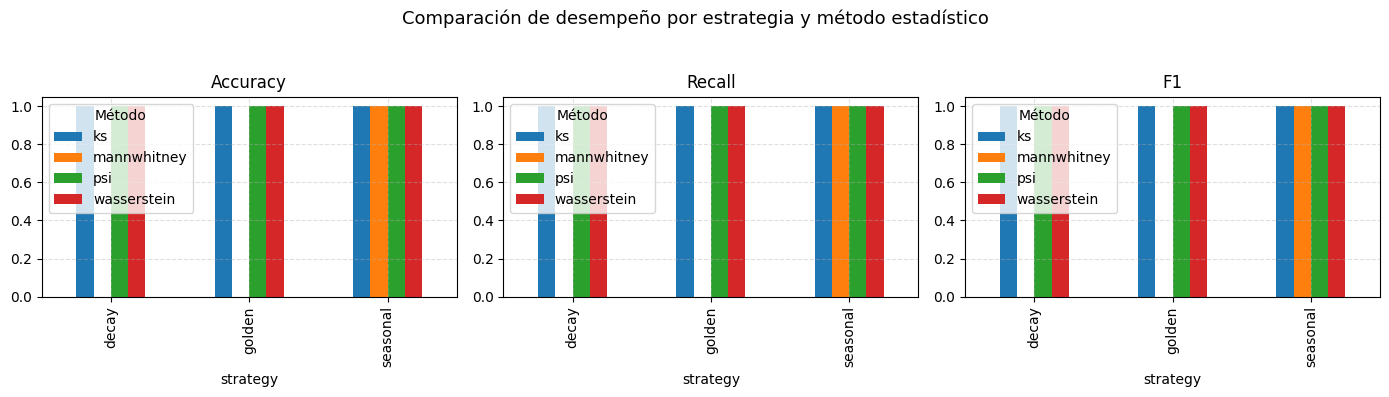

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14,4))

for ax, metric_name in zip(axes, ["Accuracy","Recall","F1"]):
    df_pivot = df_eval.pivot(index="strategy", columns="metric", values=metric_name)
    df_pivot.plot(kind="bar", ax=ax)
    ax.set_title(metric_name)
    ax.set_ylim(0, 1.05)
    ax.legend(title="Método")
    ax.grid(True, ls="--", alpha=0.4)

plt.suptitle("Comparación de desempeño por estrategia y método estadístico", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()
